## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import inspect
import os
import sys

#LPM_STYLE_ROOT = "../../lpm_style"

LPM_STYLE_ROOT = str(Path("../../lpm_style").resolve())


for mod in [m for m in list(sys.modules) if m == "perturb_lib" or m.startswith("perturb_lib.")]:
    del sys.modules[mod]

sys.path = [LPM_STYLE_ROOT] + [p for p in sys.path if "perturblib" not in p and p != LPM_STYLE_ROOT]
#os.chdir(LPM_STYLE_ROOT)

import perturb_lib as plib
from perturb_lib.models.collection.lpm import LPM
from perturb_lib.models.access import load_model as _load_model
import perturb_lib.models.access as model_access

model_access.model_catalogue["LPM"] = LPM

assert "lpm_style" in inspect.getfile(plib), f"perturb_lib resolved to {inspect.getfile(plib)}"
assert "lpm_style" in inspect.getfile(LPM), f"LPM resolved to {inspect.getfile(LPM)}"

## 2. Load checkpoints

In [2]:
_VOCAB_KEYS = {"context_symbols", "perturb_symbols", "readout_symbols", "dataset_symbols"}


def load_lpm_checkpoint(ckpt_path, *, map_location="cpu", verbose=True):
    """Load an LPM PyTorch-Lightning checkpoint into the local LPM fork.

    Args:
        ckpt_path: path to a `.ckpt` written by `pytorch_lightning`.
        map_location: forwarded to `torch.load`.
        verbose: if True, print epoch/step, dropped hparams, and vocab sizes.

    Returns:
        (model, raw):
            * `model` — LPM in `eval()` mode with weights and vocab loaded.
            * `raw`   — the raw checkpoint dict (`epoch`, `global_step`,
              `state_dict`, `hyper_parameters`, ...).

    Raises:
        RuntimeError: if the saved state dict contains keys the current model
            has no parameter for, or is missing keys the current model expects.
    """
    raw = torch.load(ckpt_path, map_location=map_location, weights_only=False)
    saved_state = raw["state_dict"]
    saved_args = dict(raw["hyper_parameters"])

    # 1. Filter saved hparams to keys the current LPM.__init__ accepts.
    valid_kwargs = set(inspect.signature(LPM.__init__).parameters)
    ctor_kwargs = {k: v for k, v in saved_args.items() if k in valid_kwargs}
    dropped = sorted(set(saved_args) - valid_kwargs)

    # 2. Instantiate via the registered factory; pad the continuous-feature layers.
    model = _load_model("LPM", ctor_kwargs)
    if "log_dose_layer.weight" in saved_state and model.log_dose_layer is None:
        model.log_dose_layer = nn.Linear(1, model.embedding_dim)
    if "time_layer.weight" in saved_state and model.time_layer is None:
        model.time_layer = nn.Linear(1, model.embedding_dim)

    # 3. Transfer weights and verify the parameter-name diff manually.
    saved_keys = set(saved_state) - _VOCAB_KEYS
    model.load_state_dict(saved_state, strict=False)
    model_keys = set(model.state_dict()) - _VOCAB_KEYS
    missing = sorted(model_keys - saved_keys)
    unexpected = sorted(saved_keys - model_keys)
    if missing or unexpected:
        raise RuntimeError(
            f"State dict incompatible:\n  missing: {missing}\n  unexpected: {unexpected}"
        )

    model.eval()

    if verbose:
        epoch = raw.get("epoch")
        step = raw.get("global_step")
        print(f"loaded LPM @ epoch={epoch} (1-indexed: {epoch + 1 if epoch is not None else '?'}), step={step}")
        if dropped:
            print(f"  dropped unknown hparams: {dropped}")
        if model.vocab is not None:
            print(
                "  vocab sizes: "
                f"dataset={len(model.vocab.dataset_vocab)}, "
                f"context={len(model.vocab.context_vocab)}, "
                f"perturb={len(model.vocab.perturb_vocab)}, "
                f"readout={len(model.vocab.readout_vocab)}"
            )

    return model, raw

In [3]:
def sanity_checks(model):
    bad = []
    for name, p in model.named_parameters():
        n_nan = torch.isnan(p).sum().item()
        n_inf = torch.isinf(p).sum().item()
        if n_nan or n_inf:
            bad.append((name, tuple(p.shape), n_nan, n_inf, p.numel()))
            print(f"  {name:40s} shape={tuple(p.shape)}  NaN={n_nan}  Inf={n_inf}  total={p.numel()}")
    
    n_layers = sum(1 for _ in model.named_parameters())
    print(f"Layers with bad values: {len(bad)} / {n_layers}")
    if not bad:
        print("All parameters finite (model is fine; check inputs/preprocessing if predictions look off).")
    else:
        print("First-corrupted hypothesis:")
        print("  - if ONLY perturb_embedding_layer -> empty-bag NaN (mode=mean/sum on empty list)")
        print("  - if log_dose_layer or time_layer present -> check raw log_dose/time values")
        print("  - if predictor.* widespread -> loss/grad blowup (bf16 + LR too high)")

In [4]:
def _embeddings_df(vocab, embedding_layer):
    df = vocab.to_pandas()
    weights = embedding_layer.weight.detach().cpu().numpy().astype(np.float32)
    df["lpm_style_embeddings"] = weights.tolist()
    return df

In [5]:
def _save_emb(df_pert, 
              df_context, 
              df_readout, 
              path
             ):
    OUTPUT_DIR = Path(path)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    df_pert.to_pickle(OUTPUT_DIR / "df_pert.pkl")
    df_context.to_pickle(OUTPUT_DIR / "df_context.pkl")
    df_readout.to_pickle(OUTPUT_DIR / "df_readout.pkl")
    
    print(f"wrote pickles to {OUTPUT_DIR.resolve()}")

In [7]:
import os
RESULTS_ROOT = Path(LPM_STYLE_ROOT) / ".plib_cache/results/all_25_epochs/LPM_1bda216b02438d13/seed_13/checkpoints/"
#OUTPUT_ROOT = Path("./files/single_run_l1000")
os.makedirs('../files/', exist_ok=True)
OUTPUT_ROOT = Path("../files/single_run_all_25_epochs")

ckpts = sorted(
    RESULTS_ROOT.glob("*.ckpt"),
    key=lambda p: p.stat().st_mtime,
)

if not ckpts:
    raise FileNotFoundError(f"No last.ckpt under {RESULTS_ROOT}. Run training first.")

for ckpt in ckpts:
    if 'epoch-epoch=0019.ckpt' in str(ckpt):
        model, _ = load_lpm_checkpoint(ckpt)
        sanity_checks(model)
    
        df_pert = _embeddings_df(model.vocab.perturb_vocab, model.perturb_embedding_layer)
        #df_context = _embeddings_df(model.vocab.context_vocab, model.context_embedding_layer)
        #df_readout = _embeddings_df(model.vocab.readout_vocab, model.readout_embedding_layer)
        #df_dataset = _embeddings_df(model.vocab.dataset_vocab, model.dataset_embedding_layer)
    
        
        
        print(f"df_pert    : {len(df_pert):>7d} rows")
        #print(f"df_context : {len(df_context):>7d} rows")
        #print(f"df_readout : {len(df_readout):>7d} rows")
        #print(f"df_dataset : {len(df_dataset):>7d} rows")
        
        #_save_emb(df_pert, 
        #          df_context, 
        #          df_readout, 
        #          OUTPUT_ROOT / f'{ckpt.name.split('.')[0].replace('-', '_').replace('=', '_')}')
        #df_dataset.to_pickle(OUTPUT_ROOT / f'{ckpt.name.split('.')[0].replace('-', '_').replace('=', '_')}' / "df_dataset.pkl")
        df_pert.to_pickle(OUTPUT_ROOT / f'{ckpt.name.split('.')[0].replace('-', '_').replace('=', '_')}' / "df_pert.pkl")
        
        
        print('Saved')
        print('\n')

loaded LPM @ epoch=19 (1-indexed: 20), step=2089120
  vocab sizes: dataset=10, context=130, perturb=37441, readout=43499
Layers with bad values: 0 / 14
All parameters finite (model is fine; check inputs/preprocessing if predictions look off).
df_pert    :   37441 rows
Saved




In [8]:
RESULTS_ROOT = Path(LPM_STYLE_ROOT) / ".plib_cache/results/l1000_25_epochs/"
#OUTPUT_ROOT = Path("./files/single_run_l1000")
OUTPUT_ROOT = Path("../files/single_run_l1000_25_epochs")

ckpts = sorted(
    RESULTS_ROOT.glob("LPM_*/seed_*/checkpoints/*.ckpt"),
    key=lambda p: p.stat().st_mtime,
)

if not ckpts:
    raise FileNotFoundError(f"No last.ckpt under {RESULTS_ROOT}. Run training first.")

for ckpt in ckpts:
    if 'epoch-epoch=0019.ckpt' in str(ckpt):
        model, _ = load_lpm_checkpoint(ckpt)
        sanity_checks(model)
    
        df_pert = _embeddings_df(model.vocab.perturb_vocab, model.perturb_embedding_layer)
        #df_context = _embeddings_df(model.vocab.context_vocab, model.context_embedding_layer)
        #df_readout = _embeddings_df(model.vocab.readout_vocab, model.readout_embedding_layer)
        #df_dataset = _embeddings_df(model.vocab.dataset_vocab, model.dataset_embedding_layer)
    
        
        
        print(f"df_pert    : {len(df_pert):>7d} rows")
        #print(f"df_context : {len(df_context):>7d} rows")
        #print(f"df_readout : {len(df_readout):>7d} rows")
        #print(f"df_dataset : {len(df_dataset):>7d} rows")
        
        #_save_emb(df_pert, 
        #          df_context, 
        #          df_readout, 
        #          OUTPUT_ROOT / f'{ckpt.name.split('.')[0].replace('-', '_').replace('=', '_')}')
        #df_dataset.to_pickle(OUTPUT_ROOT / f'{ckpt.name.split('.')[0].replace('-', '_').replace('=', '_')}' / "df_dataset.pkl")
        df_pert.to_pickle(OUTPUT_ROOT / f'{ckpt.name.split('.')[0].replace('-', '_').replace('=', '_')}' / "df_pert.pkl")
        
        print('Saved')
        print('\n')

loaded LPM @ epoch=19 (1-indexed: 20), step=255200
  vocab sizes: dataset=2, context=82, perturb=21005, readout=978
Layers with bad values: 0 / 14
All parameters finite (model is fine; check inputs/preprocessing if predictions look off).
df_pert    :   21005 rows
Saved




In [9]:
#OUTPUT_DIR = Path("./lpm_style_embeddings_epoch_5")
#OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#df_pert.to_pickle(OUTPUT_DIR / "df_pert.pkl")
#df_context.to_pickle(OUTPUT_DIR / "df_context.pkl")
#df_readout.to_pickle(OUTPUT_DIR / "df_readout.pkl")

#print(f"wrote pickles to {OUTPUT_DIR.resolve()}")

## 3. PCA Optional

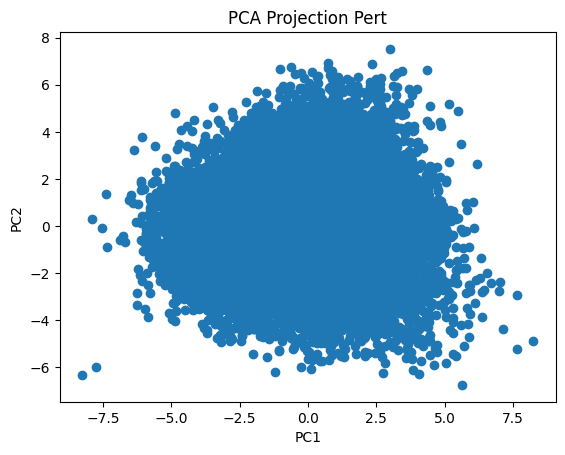

In [10]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def plot_pca(embeddings, title):
    if np.isnan(embeddings).any():
        raise ValueError(f"{title}: embeddings contain NaNs")
    scaled = StandardScaler().fit_transform(embeddings)
    pcs = PCA(n_components=2).fit_transform(scaled)
    plt.figure()
    plt.scatter(pcs[:, 0], pcs[:, 1])
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA Projection {title}")
    plt.show()


plot_pca(model.perturb_embedding_layer.weight.detach().cpu().numpy(), "Pert")
#plot_pca(model.context_embedding_layer.weight.detach().cpu().numpy(), "Context")
#plot_pca(model.readout_embedding_layer.weight.detach().cpu().numpy(), "Readout")
